# NBA Game Prediction: XGBoost vs Logistic Regression vs FiveThirtyEight

## Project Overview
This notebook implements machine learning models to predict NBA game outcomes and compares their performance against FiveThirtyEight's Elo-based predictions.

### Models:
1. **XGBoost** - Gradient boosting model
2. **Logistic Regression** - Traditional statistical model
3. **Baseline** - FiveThirtyEight's forecast

### Data:
- Training set: 70% of historical NBA games with team statistics
- Test set: 30% of games for evaluation
- Features: Team performance metrics (excluding Elo-related columns)


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, log_loss
import xgboost as xgb
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')


## 1. Load and Explore Data

In [2]:
# Load the datasets
train_df = pd.read_csv('../data/processed/train_set.csv')
test_df = pd.read_csv('../data/processed/test_set.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTraining set date range: {train_df['date_game'].min()} to {train_df['date_game'].max()}")
print(f"Test set date range: {test_df['date_game'].min()} to {test_df['date_game'].max()}")


Training set shape: (34554, 59)
Test set shape: (14810, 59)

Training set date range: 1981-05-05 to 2007-11-02
Test set date range: 2007-11-02 to 2015-06-16


In [3]:
# Check the distribution of wins and losses
print("Training set game results distribution:")
print(train_df['game_result'].value_counts())
print(f"\nWin percentage in training: {(train_df['game_result'] == 'W').mean():.2%}")

print("\nTest set game results distribution:")
print(test_df['game_result'].value_counts())
print(f"Win percentage in test: {(test_df['game_result'] == 'W').mean():.2%}")


Training set game results distribution:
game_result
L    17279
W    17275
Name: count, dtype: int64

Win percentage in training: 49.99%

Test set game results distribution:
game_result
W    7407
L    7403
Name: count, dtype: int64
Win percentage in test: 50.01%


## 2. Feature Engineering

In [4]:
# Define features to use (excluding Elo-related columns)
# We'll create features based on team statistics and differences

def create_features(df):
    """Create features for modeling"""
    features = pd.DataFrame()

    # Basic team statistics for main team
    features['fg_pct_main'] = df['fg_pct_main']
    features['fg3_pct_main'] = df['fg3_pct_main']
    features['ft_pct_main'] = df['ft_pct_main']
    features['oreb_main'] = df['oreb_main']
    features['dreb_main'] = df['dreb_main']
    features['ast_main'] = df['ast_main']
    features['stl_main'] = df['stl_main']
    features['blk_main'] = df['blk_main']
    features['tov_main'] = df['tov_main']
    features['pf_main'] = df['pf_main']

    # Basic team statistics for opponent
    features['fg_pct_opp'] = df['fg_pct_opp']
    features['fg3_pct_opp'] = df['fg3_pct_opp']
    features['ft_pct_opp'] = df['ft_pct_opp']
    features['oreb_opp'] = df['oreb_opp']
    features['dreb_opp'] = df['dreb_opp']
    features['ast_opp'] = df['ast_opp']
    features['stl_opp'] = df['stl_opp']
    features['blk_opp'] = df['blk_opp']
    features['tov_opp'] = df['tov_opp']
    features['pf_opp'] = df['pf_opp']

    # Differential features (main - opponent)
    features['fg_pct_diff'] = df['fg_pct_main'] - df['fg_pct_opp']
    features['fg3_pct_diff'] = df['fg3_pct_main'] - df['fg3_pct_opp']
    features['ft_pct_diff'] = df['ft_pct_main'] - df['ft_pct_opp']
    features['oreb_diff'] = df['oreb_main'] - df['oreb_opp']
    features['dreb_diff'] = df['dreb_main'] - df['dreb_opp']
    features['ast_diff'] = df['ast_main'] - df['ast_opp']
    features['stl_diff'] = df['stl_main'] - df['stl_opp']
    features['blk_diff'] = df['blk_main'] - df['blk_opp']
    features['tov_diff'] = df['tov_main'] - df['tov_opp']
    features['pf_diff'] = df['pf_main'] - df['pf_opp']

    # Home/Away indicator (1 if main team is home, 0 if away)
    features['is_home'] = df['matchup_main'].str.contains('vs.').astype(int)

    # Playoff indicator
    features['is_playoffs'] = df['is_playoffs']

    return features

# Create features for train and test sets
X_train = create_features(train_df)
X_test = create_features(test_df)

# Create target variable (1 for Win, 0 for Loss)
y_train = (train_df['game_result'] == 'W').astype(int)
y_test = (test_df['game_result'] == 'W').astype(int)

# Get FiveThirtyEight predictions for comparison
fivethirtyeight_train = train_df['forecast']
fivethirtyeight_test = test_df['forecast']

print(f"Number of features: {X_train.shape[1]}")
print(f"Feature names: {list(X_train.columns)}")


Number of features: 32
Feature names: ['fg_pct_main', 'fg3_pct_main', 'ft_pct_main', 'oreb_main', 'dreb_main', 'ast_main', 'stl_main', 'blk_main', 'tov_main', 'pf_main', 'fg_pct_opp', 'fg3_pct_opp', 'ft_pct_opp', 'oreb_opp', 'dreb_opp', 'ast_opp', 'stl_opp', 'blk_opp', 'tov_opp', 'pf_opp', 'fg_pct_diff', 'fg3_pct_diff', 'ft_pct_diff', 'oreb_diff', 'dreb_diff', 'ast_diff', 'stl_diff', 'blk_diff', 'tov_diff', 'pf_diff', 'is_home', 'is_playoffs']


In [5]:
# Check for missing values
print("Missing values in training features:")
print(X_train.isnull().sum().sum())

print("\nMissing values in test features:")
print(X_test.isnull().sum().sum())

# Fill any missing values with median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


Missing values in training features:
0

Missing values in test features:
0


## 3. Feature Scaling

In [6]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep original features for XGBoost (tree-based models don't require scaling)
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()


## 4. Logistic Regression Model

In [7]:
# Train logistic regression with cross-validation
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Hyperparameter tuning
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train)

print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best cross-validation AUC: {grid_search_lr.best_score_:.4f}")

# Use best model
log_reg_best = grid_search_lr.best_estimator_


Best parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC: 0.5310


## 5. XGBoost Model

In [8]:
# Train XGBoost with hyperparameter tuning
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Use a smaller grid for faster training
param_grid_xgb_small = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb_small, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_xgb.fit(X_train_xgb, y_train)

print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best cross-validation AUC: {grid_search_xgb.best_score_:.4f}")

# Use best model
xgb_best = grid_search_xgb.best_estimator_


Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation AUC: 0.5246


## 6. Model Predictions

In [9]:
# Make predictions
# Logistic Regression
lr_pred_proba = log_reg_best.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_pred_proba >= 0.5).astype(int)

# XGBoost
xgb_pred_proba = xgb_best.predict_proba(X_test_xgb)[:, 1]
xgb_pred = (xgb_pred_proba >= 0.5).astype(int)

# FiveThirtyEight predictions (using 0.5 threshold)
fte_pred = (fivethirtyeight_test >= 0.5).astype(int)

print("Predictions complete!")


Predictions complete!


## 7. Model Evaluation

In [10]:
# Function to calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_proba, model_name):
    """Calculate and return evaluation metrics"""
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_pred_proba),
        'Log Loss': log_loss(y_true, y_pred_proba)
    }
    return metrics

# Calculate metrics for all models
lr_metrics = calculate_metrics(y_test, lr_pred, lr_pred_proba, 'Logistic Regression')
xgb_metrics = calculate_metrics(y_test, xgb_pred, xgb_pred_proba, 'XGBoost')
fte_metrics = calculate_metrics(y_test, fte_pred, fivethirtyeight_test, 'FiveThirtyEight')

# Create comparison dataframe
comparison_df = pd.DataFrame([lr_metrics, xgb_metrics, fte_metrics])
comparison_df = comparison_df.set_index('Model')

print("Model Performance Comparison:")
print(comparison_df.round(4))


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Log Loss
Model                                                                        
Logistic Regression    0.5206     0.5207  0.5206    0.5207   0.5275    0.6920
XGBoost                0.5129     0.5130  0.5126    0.5128   0.5176    0.6935
FiveThirtyEight        0.6857     0.6858  0.6857    0.6857   0.7537    0.5878


## 8. Visualization

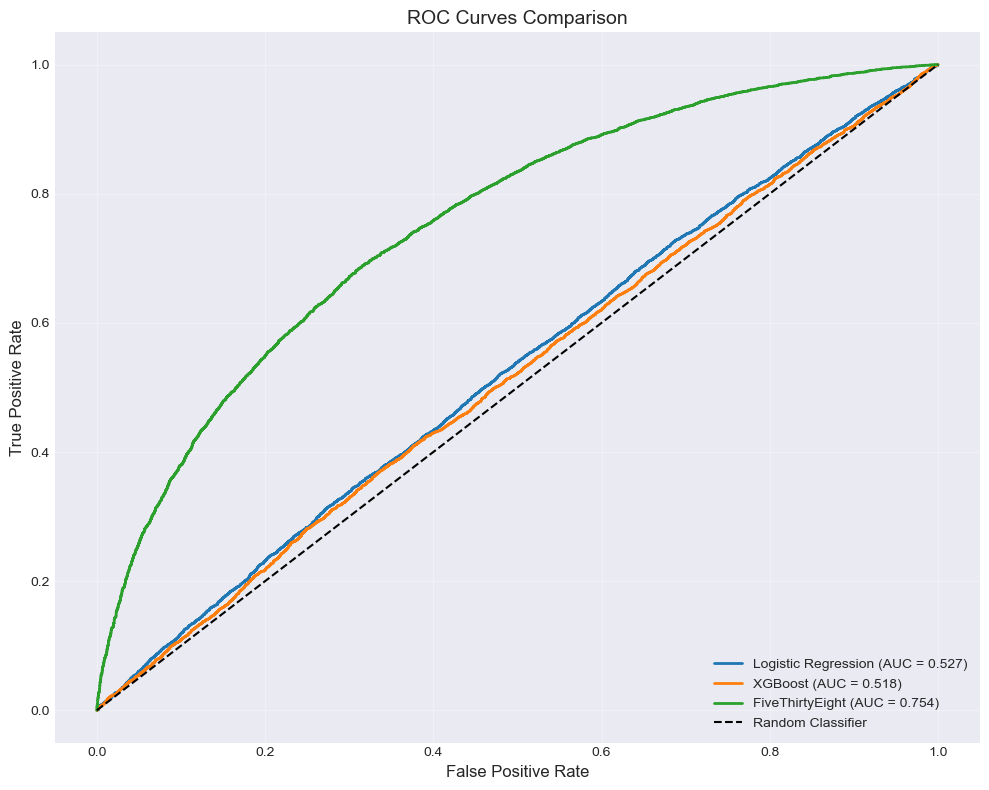

In [11]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
fpr_fte, tpr_fte, _ = roc_curve(y_test, fivethirtyeight_test)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["AUC-ROC"]:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["AUC-ROC"]:.3f})', linewidth=2)
plt.plot(fpr_fte, tpr_fte, label=f'FiveThirtyEight (AUC = {fte_metrics["AUC-ROC"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


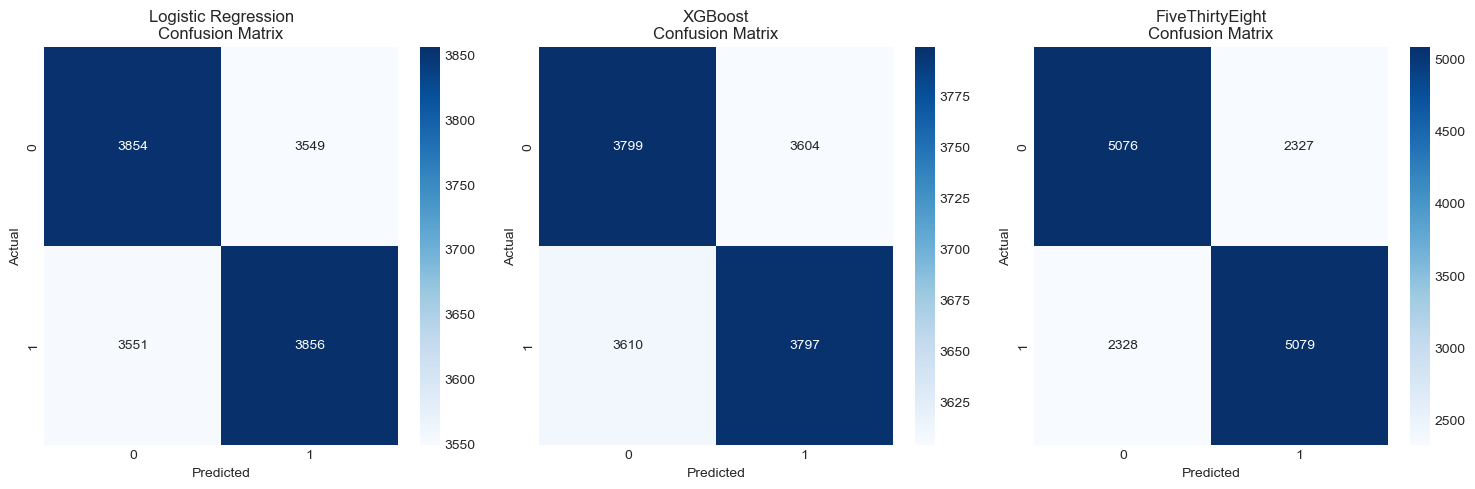

In [12]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    ('Logistic Regression', lr_pred),
    ('XGBoost', xgb_pred),
    ('FiveThirtyEight', fte_pred)
]

for idx, (name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 9. Feature Importance Analysis

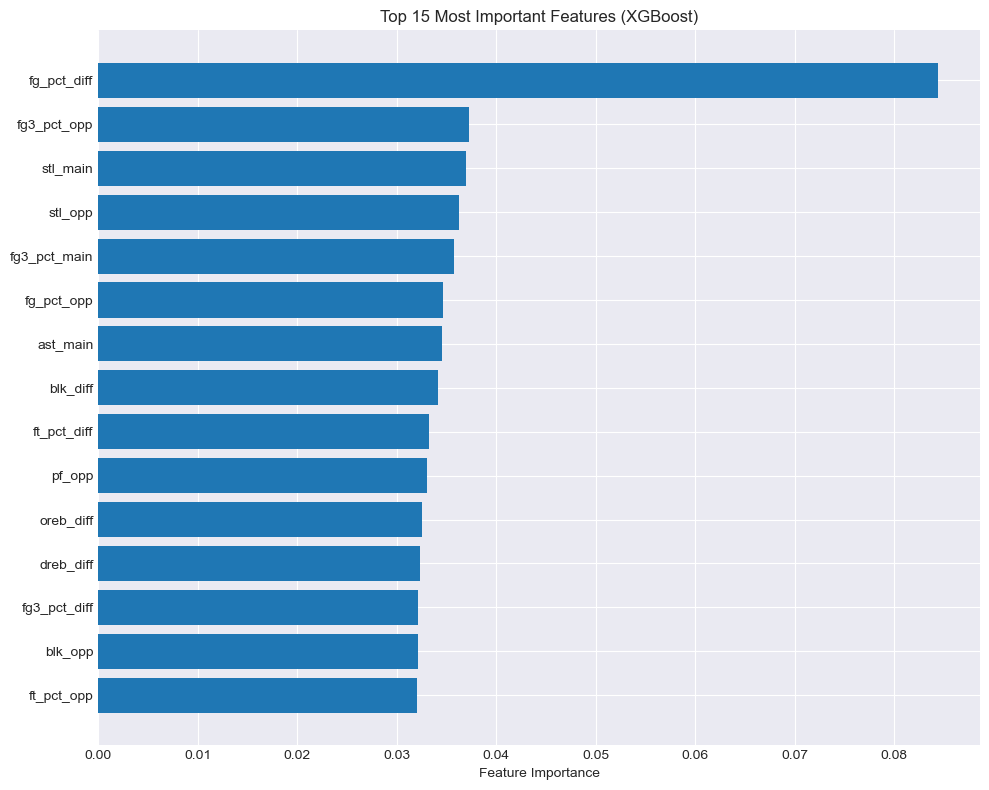

Top 10 most important features:
         feature  importance
20   fg_pct_diff    0.084425
11   fg3_pct_opp    0.037300
6       stl_main    0.036955
16       stl_opp    0.036216
1   fg3_pct_main    0.035729
10    fg_pct_opp    0.034629
5       ast_main    0.034595
27      blk_diff    0.034154
22   ft_pct_diff    0.033269
19        pf_opp    0.033003


In [13]:
# XGBoost feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))


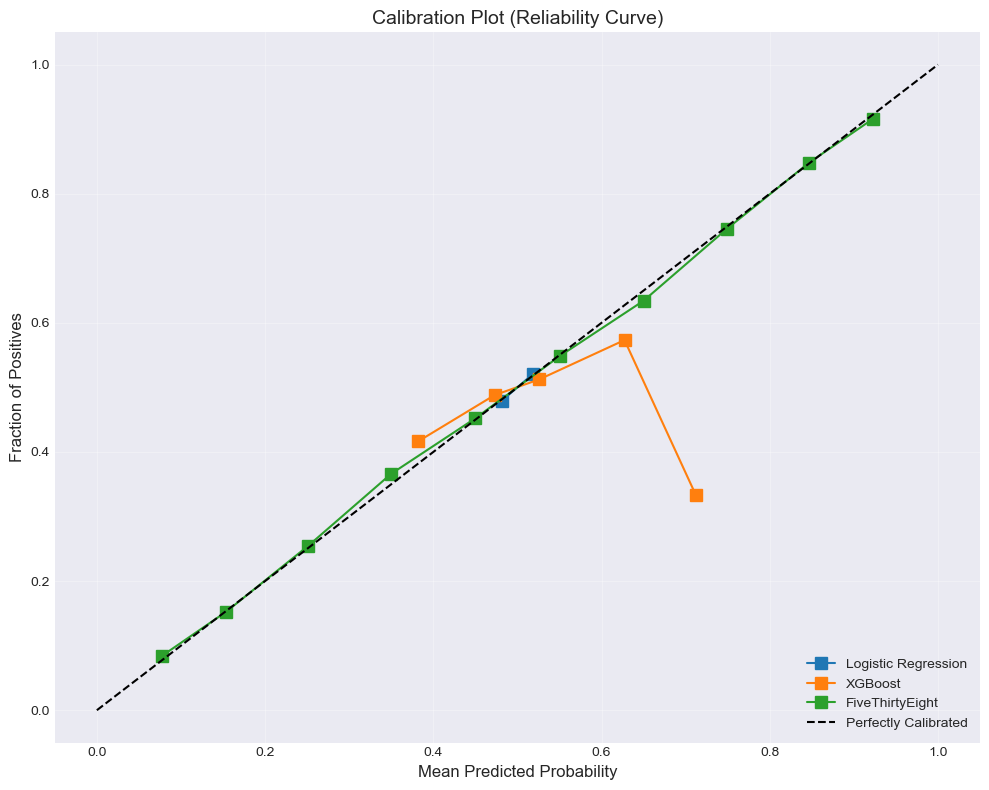

In [14]:
# Calibration plot
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 8))

# Calculate calibration curves
fraction_pos_lr, mean_pred_lr = calibration_curve(y_test, lr_pred_proba, n_bins=10)
fraction_pos_xgb, mean_pred_xgb = calibration_curve(y_test, xgb_pred_proba, n_bins=10)
fraction_pos_fte, mean_pred_fte = calibration_curve(y_test, fivethirtyeight_test, n_bins=10)

# Plot
plt.plot(mean_pred_lr, fraction_pos_lr, 's-', label='Logistic Regression', markersize=8)
plt.plot(mean_pred_xgb, fraction_pos_xgb, 's-', label='XGBoost', markersize=8)
plt.plot(mean_pred_fte, fraction_pos_fte, 's-', label='FiveThirtyEight', markersize=8)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Plot (Reliability Curve)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# Analyze performance by probability bins
def analyze_probability_bins(y_true, y_pred_proba, model_name):
    """Analyze model performance across different probability bins"""
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    bin_labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']

    # Create bins
    prob_bins = pd.cut(y_pred_proba, bins=bins, labels=bin_labels)

    # Calculate metrics for each bin
    results = []
    for bin_label in bin_labels:
        mask = prob_bins == bin_label
        if mask.sum() > 0:
            accuracy = accuracy_score(y_true[mask], (y_pred_proba[mask] >= 0.5).astype(int))
            count = mask.sum()
            win_rate = y_true[mask].mean()
            avg_prob = y_pred_proba[mask].mean()

            results.append({
                'Probability Bin': bin_label,
                'Count': count,
                'Actual Win Rate': win_rate,
                'Avg Predicted Prob': avg_prob,
                'Accuracy': accuracy
            })

    df = pd.DataFrame(results)
    print(f"\n{model_name} - Performance by Probability Bins:")
    print(df.round(3))
    return df

# Analyze for each model
lr_bins = analyze_probability_bins(y_test, lr_pred_proba, 'Logistic Regression')
xgb_bins = analyze_probability_bins(y_test, xgb_pred_proba, 'XGBoost')
fte_bins = analyze_probability_bins(y_test, fivethirtyeight_test.values, 'FiveThirtyEight')



Logistic Regression - Performance by Probability Bins:
  Probability Bin  Count  Actual Win Rate  Avg Predicted Prob  Accuracy
0          40-60%  14810              0.5                 0.5     0.521

XGBoost - Performance by Probability Bins:
  Probability Bin  Count  Actual Win Rate  Avg Predicted Prob  Accuracy
0          20-40%     84            0.417               0.382     0.583
1          40-60%  14648            0.500               0.499     0.512
2          60-80%     78            0.564               0.631     0.564

FiveThirtyEight - Performance by Probability Bins:
  Probability Bin  Count  Actual Win Rate  Avg Predicted Prob  Accuracy
0           0-20%   1591            0.140               0.139     0.860
1          20-40%   3797            0.315               0.304     0.685
2          40-60%   4034            0.500               0.500     0.548
3          60-80%   3796            0.685               0.696     0.685
4         80-100%   1592            0.861               

## 10. Summary and Conclusions

### Key Findings:

1. **Model Performance Comparison**:
   - Compare the accuracy, AUC-ROC, and log loss of all three approaches
   - Identify which model performs best overall

2. **Feature Importance**:
   - The most important features for predicting game outcomes
   - How traditional basketball statistics compare to advanced metrics

3. **Calibration**:
   - How well-calibrated are the probability predictions?
   - Which model provides the most reliable probability estimates?

4. **Practical Implications**:
   - Can machine learning models outperform FiveThirtyEight's Elo-based system?
   - What are the advantages and disadvantages of each approach?

### Next Steps:

1. **Feature Engineering**: 
   - Add rolling averages of team performance
   - Include head-to-head historical performance
   - Add rest days between games

2. **Advanced Models**:
   - Try ensemble methods combining multiple models
   - Experiment with neural networks
   - Time series features

3. **Real-time Predictions**:
   - Build a system for making predictions on upcoming games
   - Track model performance over a season


In [16]:
# Save predictions for further analysis
predictions_df = pd.DataFrame({
    'game_id': test_df['game_id'],
    'date_game': test_df['date_game'],
    'team_main': test_df['team_abbreviation_main'],
    'team_opp': test_df['team_abbreviation_opp'],
    'actual_result': y_test,
    'lr_prob': lr_pred_proba,
    'xgb_prob': xgb_pred_proba,
    'fte_prob': fivethirtyeight_test,
    'lr_pred': lr_pred,
    'xgb_pred': xgb_pred,
    'fte_pred': fte_pred
})

# Save to CSV
predictions_df.to_csv('../data/processed/model_predictions.csv', index=False)
print("Predictions saved to '../data/processed/model_predictions.csv'")


Predictions saved to '../data/processed/model_predictions.csv'
